# Lorenz-96: ETKF

## 1. Overview

This tutorial applies the ensemble transform Kalman filter (ETKF) to the
40-variable Lorenz-96 model with fully observed, noisy observations. It
follows `docs/notebook_spec.md`; the paired CLI script is
`examples/scripts/l96_etkf.py`.

## 2. Model

The Lorenz-96 model describes $J$ variables on a periodic ring,

$$
\dot{x}_j = (x_{j+1} - x_{j-2})\, x_{j-1} - x_j + F,
\qquad j = 1, \dots, J \ (\text{indices mod } J),
$$

with $J = 40$ and forcing $F = 8$, a standard chaotic configuration
(`da.l96.lorenz96`). The forecast map $M$ integrates with fourth-order
Runge-Kutta (`da.scheme.rk4`), time step $\delta t$, over one assimilation
window of $n_{\mathrm{obs}}$ steps ($\Delta t = n_{\mathrm{obs}}\,\delta t$).

## 3. Observation

The full state is observed with additive Gaussian noise every assimilation
window:

$$
y_k = H x_k + \varepsilon_k, \qquad H = I_J, \qquad
\varepsilon_k \sim N(0, R), \quad R = r_0^2 I_J,
$$

so the observation-noise scale is
$\sigma_{\mathrm{obs}} = \sqrt{\operatorname{tr}(R)/N_y} = r_0$.

## 4. DA method

The **ensemble transform Kalman filter (ETKF)** represents the forecast
uncertainty by an ensemble $X^f \in \mathbb{R}^{m \times N_x}$ with mean
$\bar{x}^f$ and anomaly matrix $A^f$ (rows $x^{f,(i)} - \bar{x}^f$).

**Forecast step:** each member is propagated by the model,
$x_k^{f,(i)} = M(x_{k-1}^{a,(i)})$.

**Analysis step:** with $\tilde{P} = \big[(m-1) I + (H A^f)^{\mathsf T}
R^{-1} (H A^f)\big]^{-1}$,

$$
\bar{x}^a = \bar{x}^f + A^f\, \tilde{P}\, (H A^f)^{\mathsf T} R^{-1}
\,(y - H \bar{x}^f),
\qquad
A^a = A^f \big[(m-1)\, \tilde{P}\big]^{1/2}.
$$

Multiplicative inflation is applied to the anomalies, $A \to \alpha A$
(covariance inflation $\alpha^2$), to compensate for sampling error.

## 5. Parameters

| Parameter | Symbol | Value |
| --- | --- | --- |
| dimension / forcing | $J$, $F$ | 40, 8 |
| integration step | $\delta t$ | 0.01 |
| steps per window | $n_{\mathrm{obs}}$ | 5 |
| assimilation cycles | | 200 |
| truth spin-up steps | | 500 |
| observation noise variance | $r_0^2$ | 1.0 |
| ensemble size | $m$ | 20 |
| multiplicative inflation | $\alpha$ | 1.05 |
| initial ensemble spread | | 0.5 |
| random seed | | 11 |

Without localization, the ensemble must be large enough to span the
unstable subspace: $m = 12$ diverges on this setting while $m = 20$
tracks the truth (compare the LETKF tutorial, which succeeds with
$m = 12$ thanks to localization). The script exposes `--cycles`,
`--dimension`, `--ensemble-size`, `--obs-noise-variance`, `--inflation`,
`--dt`, `--obs-interval`, and `--seed`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from da.l96 import lorenz96
from da.scheme import rk4
from da.etkf import ETKF

def l96_step(x, dt, forcing=8.0):
    return rk4(lorenz96, 0.0, np.asarray(x), (forcing,), dt)


def advance(x, dt, n_steps):
    x = np.asarray(x, dtype=float).copy()
    for _ in range(n_steps):
        x = l96_step(x, dt)
    return x


def rmse(x, truth):
    return float(np.sqrt(np.mean((np.asarray(x) - np.asarray(truth)) ** 2)))

J, dt, obs_interval, cycles, seed = 40, 0.01, 5, 200, 11
m, alpha = 20, 1.05
H = np.eye(J)
R = np.eye(J)

## 6. Truth and observations

After a 500-step spin-up onto the attractor, truth and full-state
observations are shown as space-time (Hovmöller) plots.

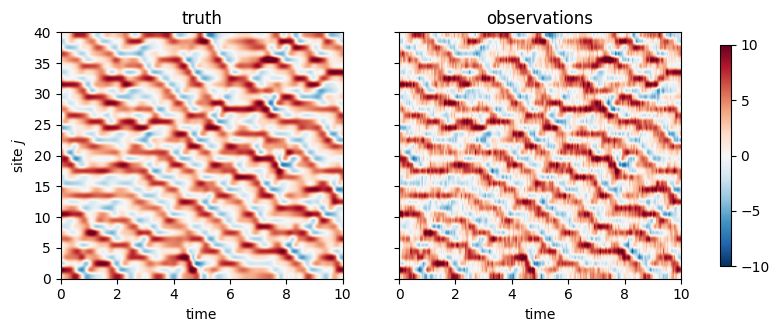

In [2]:
rng = np.random.default_rng(seed)
x = 8.0 * np.ones(J)
x[0] += 0.01
x = advance(x, dt, 500)  # spin-up onto the attractor
truth = [x.copy()]
obs = [H @ x + rng.multivariate_normal(np.zeros(J), R)]
for _ in range(cycles):
    x = advance(x, dt, obs_interval)
    truth.append(x.copy())
    obs.append(H @ x + rng.multivariate_normal(np.zeros(J), R))
truth, obs = np.asarray(truth), np.asarray(obs)
t = np.arange(cycles + 1) * dt * obs_interval

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
for ax, field, title in ((axes[0], truth, "truth"), (axes[1], obs, "observations")):
    im = ax.imshow(field.T, aspect="auto", origin="lower", cmap="RdBu_r",
                   vmin=-10, vmax=10, extent=[t[0], t[-1], 0, J])
    ax.set_title(title)
    ax.set_xlabel("time")
axes[0].set_ylabel("site $j$")
fig.colorbar(im, ax=axes, shrink=0.9)

## 7. Assimilation results

In [3]:
X0 = truth[0] + 0.5 * rng.standard_normal((m, J))
filt = ETKF(l96_step, H, R, alpha=alpha)
filt.initialize(X0)

means = [filt.X.mean(axis=0)]
rmses = [rmse(means[0], truth[0])]
for k in range(1, cycles + 1):
    for _ in range(obs_interval):
        filt.forecast(dt)
    filt.update(obs[k])
    means.append(filt.X.mean(axis=0))
    rmses.append(rmse(means[-1], truth[k]))
means, rmses = np.asarray(means), np.asarray(rmses)

Text(0, 0.5, 'site $j$')

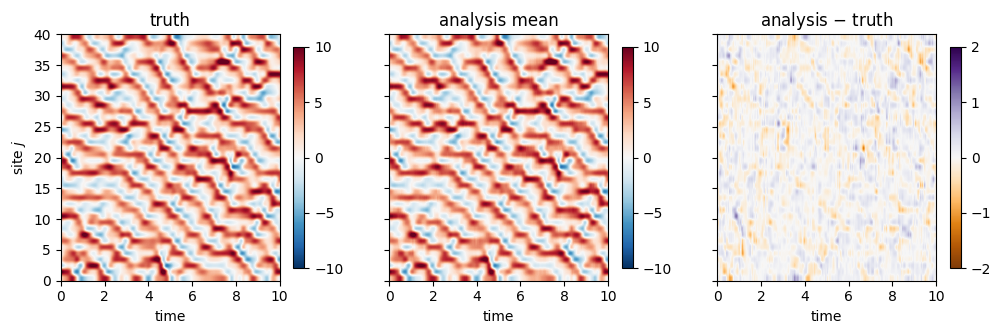

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for ax, field, title, (vmin, vmax), cmap in (
    (axes[0], truth, "truth", (-10, 10), "RdBu_r"),
    (axes[1], means, "analysis mean", (-10, 10), "RdBu_r"),
    (axes[2], means - truth, "analysis $-$ truth", (-2, 2), "PuOr"),
):
    im = ax.imshow(field.T, aspect="auto", origin="lower", cmap=cmap,
                   vmin=vmin, vmax=vmax, extent=[t[0], t[-1], 0, J])
    ax.set_title(title)
    ax.set_xlabel("time")
    fig.colorbar(im, ax=ax, shrink=0.9)
axes[0].set_ylabel("site $j$")

## 8. RMSE

observation noise scale: 1.000
mean RMSE (2nd half): 0.214


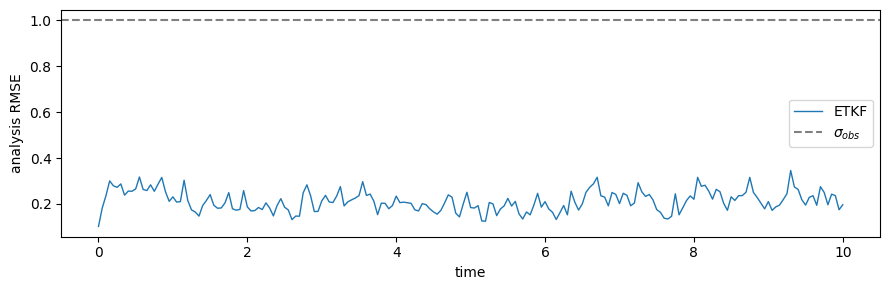

In [5]:
sigma_obs = np.sqrt(np.trace(R) / R.shape[0])
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t, rmses, color="tab:blue", lw=1, label="ETKF")
ax.axhline(sigma_obs, color="gray", ls="--", label=r"$\sigma_{obs}$")
ax.set_xlabel("time")
ax.set_ylabel("analysis RMSE")
ax.legend()
fig.tight_layout()

half = cycles // 2
print(f"observation noise scale: {sigma_obs:.3f}")
print(f"mean RMSE (2nd half): {rmses[half:].mean():.3f}")

## 9. Summary

With $m = 20$ members and inflation $\alpha = 1.05$, the ETKF analysis
RMSE settles near $0.2$, well below the observation-noise scale
$\sigma_{\mathrm{obs}} = 1$; the error Hovmöller plot shows no growing
structures. Reducing the ensemble below the dimension of the unstable
subspace (e.g. $m = 12$) leads to filter divergence, which motivates the
localized variant in the LETKF tutorial.